In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import j1

In [2]:
def intensity_annular_aperture(r_rad_array, wavel, D_aperture, D_obscuration):
    '''
    Calculate the intensity through an aperture with a central obscuration
    Ref. 'E-REP-MPIA-1203 0-1 xx-10-2024', Sec. 4.4

    INPUTS:
    - r_rad_array: 2D array of radial distances from the center (units radians)
    - wavel: wavelength (units meters)
    - D_aperture: aperture diameter (units meters)
    - D_obscuration: obscuration diameter (units meters)

    OUTPUTS:
    - I_r_array: 2D array of intensity on the detector
    '''


    nu_ = np.pi * r_rad_array * D_aperture / wavel # unitless

    eps_ = D_obscuration / D_aperture # unitless
    
    # see Eqn. 43 in 'E-REP-MPIA-1203 0-1 xx-10-2024'
    I_r = (1/(1-eps_**2)**2) * ( (2*j1(nu_)/nu_) - eps_**2 * (2*j1(nu_*eps_)/(nu_*eps_)) ) ** 2

    return I_r

In [ ]:
# Create a 2D array of distances from the center in arcseconds, with each pixel 6 mas
size = 2048 
pixel_scale_mas = 6.0  # milliarcseconds per pixel
pixel_scale_arcsec = pixel_scale_mas / 1000.0  # arcseconds per pixel

y, x = np.indices((size, size))
center = (size // 2, size // 2)
r_pix = np.sqrt((x - center[1])**2 + (y - center[0])**2)
test_array_arcsec = r_pix * pixel_scale_arcsec

# convert to radians
test_array_rad = test_array_arcsec / ( 3600 * (180/np.pi ) )

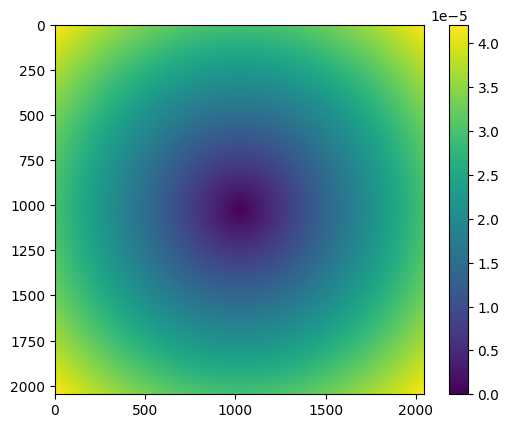

In [16]:
plt.imshow(test_array_rad)
plt.colorbar()
plt.show()

In [19]:
test = intensity_annular_aperture(r_rad_array=test_array_rad, wavel=1e-6, D_aperture=1, D_obscuration=0.5)

/var/folders/wb/zn41c4yx58z1ktmcwgv62zyr0000gn/T/ipykernel_13644/2191615273.py:22: RuntimeWarning: invalid value encountered in divide
  I_r = (1/(1-eps_**2)**2) * ( (2*j1(nu_)/nu_) - eps_**2 * (2*j1(nu_*eps_)/(nu_*eps_)) ) ** 2


In [ ]:
plt.imshow(test)
plt.colorbar()
plt.show()